Agrupar perfiles de sueño
💤 Análisis de Perfiles de Sueño con K-Means

Una empresa especializada en salud del sueño desea analizar los hábitos de descanso de cientos de personas.

Se han recogido datos sobre cómo duermen los usuarios, y ahora tu misión es agrupar a los individuos en diferentes tipos de "dormidores" usando aprendizaje no supervisado.



🎯 Objetivo

Crear un sistema en Python que genere perfiles de sueño sintéticos, los agrupe en 3 categorías usando K-Means Clustering, y visualice los resultados.



🧩 Estructura que debes seguir

1. SleepProfile

Clase que representa el perfil de sueño de una persona.

Atributos:

duration: duración promedio del sueño en horas (ej. 7.5)

latency: tiempo promedio para quedarse dormido en minutos (ej. 25)

wakeups: cantidad de despertares durante la noche (ej. 2)

variability: variabilidad en la hora de irse a dormir, en minutos (ej. 35)

Métodos:

to_vector(self): Devuelve la información del perfil como una lista [duration, latency, wakeups, variability].



2. SleepDatasetGenerator

Clase que genera una lista de objetos SleepProfile con datos sintéticos y realistas.

Constructor:

__init__(self, n=300): genera n perfiles (por defecto 300).

Método:

generate(self): retorna una lista de objetos SleepProfile, donde los atributos se generan así:

duration: distribución normal con media 7 horas y desviación estándar 1.2 → np.random.normal(7, 1.2, n)

latency: distribución normal positiva (usar np.abs) con media 20 y std 10

wakeups: distribución Poisson con media 1.5 → np.random.poisson(1.5, n)

variability: distribución normal positiva con media 30 y std 15



3. SleepClusterer

Clase que entrena un modelo K-Means y agrupa los perfiles.

Constructor:

__init__(self, n_clusters=3): crea un modelo KMeans con 3 clústeres y un StandardScaler para escalar los datos antes de entrenar.

Métodos:

fit(self, profiles): recibe una lista de SleepProfile, los convierte a vectores, normaliza con StandardScaler y entrena el modelo. Retorna X_scaled y las etiquetas de clúster (labels).

get_cluster_centers(self): devuelve los centros de clúster transformados a su escala original (usa scaler.inverse_transform).



4. SleepAnalysisExample

Clase que ejecuta todo el análisis.

Método:

run(self):

Genera los perfiles usando SleepDatasetGenerator.

Agrupa los perfiles usando SleepClusterer con 3 grupos.

Crea un DataFrame para mostrar resultados.

Imprime los centroides (promedios de cada grupo).

Grafica los perfiles usando matplotlib (eje X: duración, eje Y: variabilidad).



🛠 Requisitos mínimos

Usar numpy para generar datos sintéticos.

Usar scikit-learn para KMeans y StandardScaler.

Usar matplotlib para graficar los resultados.

Organizar el código en clases separadas como se indica.

Mostrar en consola los centroides de cada grupo.

Graficar los grupos usando diferentes colores.



📈 ¿Qué deberías mostrar al final?

Los centroides de los grupos, interpretando lo que caracteriza a cada uno.

Un gráfico de dispersión donde se vea la agrupación de perfiles por:

Eje X: Duración del sueño

Eje Y: Variabilidad de hora de dormir

Comentarios sobre posibles tipos de durmientes: ¿hay un grupo de "insomnes"? ¿otro de "buenos durmientes"?



🧪 Ejemplo de uso

example = SleepAnalysisExample()
example.run()


Salida esperada

📌 Centroides de los grupos:

Grupo 0: Duración=6.30h, Latencia=19.3min, Despertares=1.2, Variabilidad=39.6min

Grupo 1: Duración=6.79h, Latencia=18.9min, Despertares=3.4, Variabilidad=26.5min

Grupo 2: Duración=7.98h, Latencia=18.6min, Despertares=1.0, Variabilidad=22.3min










Practicar con numpy para generar datos, con el algoritmo de k-medias para agrupar perfiles de sueño, con pandas y matplotlib para graficar los resultados obtenidos.


# Solucion:

--- Iniciando Análisis de Sueño ---


C:\Users\Vaquita\anaconda3\envs\base2\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



📌 Centroides de los grupos (Arquetipos de durmientes):

Grupo 0:
  - Duración (h): 7.77
  - Latencia (min): 18.14
  - Despertares: 0.91
  - Variabilidad (min): 37.58

Grupo 1:
  - Duración (h): 6.62
  - Latencia (min): 16.86
  - Despertares: 2.75
  - Variabilidad (min): 26.21

Grupo 2:
  - Duración (h): 6.23
  - Latencia (min): 26.79
  - Despertares: 0.68
  - Variabilidad (min): 22.02

Gráfico generado.


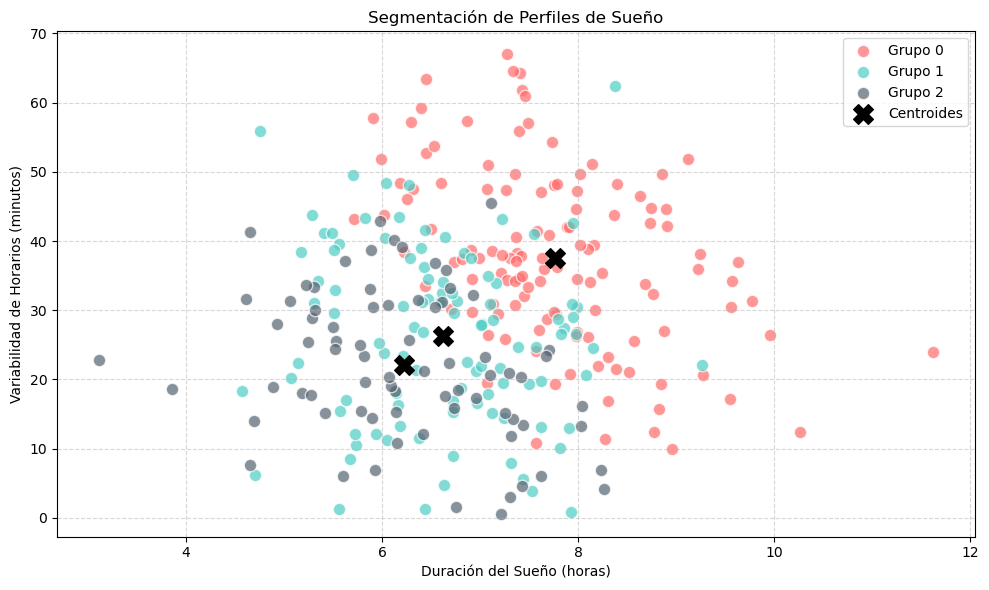

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

class SleepProfile:
    def __init__(self, duration, latency, wakeups, variability):
        self.duration = duration
        self.latency = latency
        self.wakeups = wakeups
        self.variability = variability

    def to_vector(self):

        return [self.duration, self.latency, self.wakeups, self.variability]


class SleepDatasetGenerator:
    def __init__(self, n=300):
        self.n = n

    def generate(self):

        np.random.seed(42)
        

        durations = np.random.normal(7, 1.2, self.n)
        latencies = np.abs(np.random.normal(20, 10, self.n))
        wakeups = np.random.poisson(1.5, self.n)
        variabilities = np.abs(np.random.normal(30, 15, self.n))

        profiles = []
        for i in range(self.n):
            profiles.append(SleepProfile(durations[i], latencies[i], wakeups[i], variabilities[i]))
        return profiles


class SleepClusterer:
    def __init__(self, n_clusters=3):
        self.n_clusters = n_clusters

        self.kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

        self.scaler = StandardScaler()

    def fit(self, profiles):

        data = np.array([p.to_vector() for p in profiles])
        

        X_scaled = self.scaler.fit_transform(data)

        self.kmeans.fit(X_scaled)
        
        return data, self.kmeans.labels_

    def get_cluster_centers(self):

        return self.scaler.inverse_transform(self.kmeans.cluster_centers_)


class SleepAnalysisExample:
    def run(self):
        print("--- Iniciando Análisis de Sueño ---")
        
        generator = SleepDatasetGenerator(n=300)
        profiles = generator.generate()
        
        clusterer = SleepClusterer(n_clusters=3)
        original_data, labels = clusterer.fit(profiles)
        centers = clusterer.get_cluster_centers()
        
        df = pd.DataFrame(original_data, columns=['Duration', 'Latency', 'Wakeups', 'Variability'])
        df['Cluster'] = labels
        
        print("\n📌 Centroides de los grupos (Arquetipos de durmientes):")
        feature_names = ['Duración (h)', 'Latencia (min)', 'Despertares', 'Variabilidad (min)']
        
        for i, center in enumerate(centers):
            print(f"\nGrupo {i}:")
            for name, val in zip(feature_names, center):
                print(f"  - {name}: {val:.2f}")

        plt.figure(figsize=(10, 6))
        colors = ['#FF6B6B', '#4ECDC4', '#556270']
        
        for i in range(3):
            cluster_data = df[df['Cluster'] == i]
            plt.scatter(cluster_data['Duration'], cluster_data['Variability'], 
                       label=f'Grupo {i}', c=colors[i], alpha=0.7, edgecolors='white', s=80)
            
        plt.scatter(centers[:, 0], centers[:, 3], c='black', marker='X', s=200, label='Centroides')
        
        plt.title('Segmentación de Perfiles de Sueño')
        plt.xlabel('Duración del Sueño (horas)')
        plt.ylabel('Variabilidad de Horarios (minutos)')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        
        plt.savefig('sleep_analysis.png')
        print("\nGráfico generado.")

if __name__ == "__main__":
    example = SleepAnalysisExample()
    example.run()

Casos de prueba

Suspenso: 0, Aprobado: 3 de 3 pruebas

test_centroid_count

test_fit_clustering

test_generate_profiles